# 📊 Model ML & Kalkulus Bisnis
### Analisis Matematika untuk Optimasi Usaha
---
**Topik yang dibahas:**
1. Model Biaya Produksi (Integral Dasar)
2. Pendapatan & Luas Daerah
3. Desain Volume Botol (Tabung Terpancung)
4. Model Pertumbuhan Penjualan (Eksponensial)
5. Optimasi Keuntungan (Turunan = 0)
6. Model ML: Prediksi Keuntungan & Optimasi

In [1]:
# ─── Install & Import ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import integrate, optimize
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans', 'axes.grid': True, 'grid.alpha': 0.3})
print('✅ Library berhasil di-import')

ModuleNotFoundError: No module named 'numpy'

## 🔧 Data Utama (dari Excel)

In [2]:
# ─── Data dari sheet Data Utama ──────────────────────────────────────
modal_awal       = 120000    # Rp
pendapatan_hari  = 350000    # Rp/hari
harga_jual       = 10000     # Rp/cup
modal_per_cup    = 0.5    # Rp/cup

# Dimensi Botol
d_atas   = 9     # cm
d_bawah  = 5.5   # cm
tinggi   = 12    # cm
r1       = d_atas  / 2
r2       = d_bawah / 2

# Kalkulasi dasar
pendapatan_bersih  = pendapatan_hari - modal_awal
keuntungan_per_cup = harga_jual - modal_per_cup

print('='*50)
print('📋  RINGKASAN DATA UTAMA')
print('='*50)
print(f'Modal Awal          : Rp {modal_awal}')
print(f'Pendapatan/Hari     : Rp {pendapatan_hari}')
print(f'Pendapatan Bersih   : Rp {pendapatan_bersih}')
print(f'Harga Jual/Cup      : Rp {harga_jual}')
print(f'Modal/Cup           : Rp {modal_per_cup}')
print(f'Keuntungan/Cup      : Rp {keuntungan_per_cup}')
print(f'Radius Atas  (r₁)   : {r1} cm')
print(f'Radius Bawah (r₂)   : {r2} cm')
print(f'Tinggi Botol (h)    : {tinggi} cm')

📋  RINGKASAN DATA UTAMA
Modal Awal          : Rp 120000
Pendapatan/Hari     : Rp 350000
Pendapatan Bersih   : Rp 230000
Harga Jual/Cup      : Rp 10000
Modal/Cup           : Rp 0.5
Keuntungan/Cup      : Rp 9999.5
Radius Atas  (r₁)   : 4.5 cm
Radius Bawah (r₂)   : 2.75 cm
Tinggi Botol (h)    : 12 cm


---
## 1. 📐 Model Biaya Produksi (Integral Dasar)
**Konsep:** Total biaya = ∫₀ᵠ MC(q) dq, di mana MC adalah biaya marginal (konstan)

Total Biaya: $ TC(q) = \int_0^q MC \, dq = MC \cdot q $

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# --- SETUP DATA (Pastikan harga_jual > modal_per_cup agar ada BEP) ---
modal_per_cup = 5000   # Contoh: Rp 5.000
harga_jual = 8000      # Contoh: Rp 8.000
q_max = 100            # Maksimum produksi untuk simulasi
q_arr = np.linspace(0, q_max, 300)

# --- DEFINISI FUNGSI ---
# TC(q) = Total Cost (Biaya Variabel saja dalam kasus ini)
TC = lambda q: modal_per_cup * q
# TR(q) = Total Revenue (Pendapatan)
TR = lambda q: harga_jual * q
# Profit = TR - TC
profit = lambda q: TR(q) - TC(q)

# --- PENCARIAN BEP (PENGAMAN ERROR) ---
try:
    # Cek apakah tanda profit di ujung-ujung rentang berbeda (Syarat Brentq)
    if profit(0.01) * profit(q_max) < 0:
        bep = optimize.brentq(profit, 0.01, q_max)
    else:
        # Jika tidak beda tanda, gunakan fsolve (lebih fleksibel)
        # atau asumsikan BEP di luar rentang ini
        bep_guess = optimize.fsolve(profit, 1)[0]
        bep = bep_guess if bep_guess > 0 else 0
except:
    bep = 0

# --- VISUALISASI ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Biaya Produksi – Analisis BEP', fontsize=14, fontweight='bold')

# Plot 1: TC vs TR
ax = axes[0]
ax.plot(q_arr, TC(q_arr), 'r-', lw=2, label='Total Biaya TC(q)')
ax.plot(q_arr, TR(q_arr), 'g-', lw=2, label='Total Pendapatan TR(q)')

# Arsir zona untung/rugi hanya jika bep masuk akal
if 0 < bep < q_max:
    ax.fill_between(q_arr, TC(q_arr), TR(q_arr), where=(q_arr > bep),
                    alpha=0.15, color='green', label='Zona Untung')
    ax.fill_between(q_arr, TC(q_arr), TR(q_arr), where=(q_arr < bep),
                    alpha=0.15, color='red', label='Zona Rugi')
    ax.axvline(bep, color='orange', ls='--', label=f'BEP = {bep:.1f} cup')

ax.set_xlabel('Jumlah Produksi (cup)')
ax.set_ylabel('Nilai (Rp)')
ax.set_title('Kurva TC vs TR')
ax.legend(fontsize=8)
ax.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Profit
ax2 = axes[1]
ax2.plot(q_arr, profit(q_arr), 'b-', lw=2, label='Profit π(q)')
ax2.axhline(0, color='k', lw=0.8)

if 0 < bep < q_max:
    ax2.axvline(bep, color='orange', ls='--', label=f'BEP q={bep:.1f}')
    ax2.fill_between(q_arr, profit(q_arr), 0, where=(profit(q_arr) > 0), alpha=0.2, color='green')
    ax2.fill_between(q_arr, profit(q_arr), 0, where=(profit(q_arr) < 0), alpha=0.2, color='red')

ax2.set_xlabel('Jumlah Produksi (cup)')
ax2.set_ylabel('Profit (Rp)')
ax2.set_title('Kurva Profit')
ax2.legend(fontsize=8)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- OUTPUT TEXT ---
print(f"{' HASIL ANALISIS ':=^30}")
print(f'Harga Jual      : Rp {harga_jual}')
print(f'Modal per Cup   : Rp {modal_per_cup}')
print(f'BEP ditemukan   : {bep:.2f} cup')
print(f'Profit pd q=50  : Rp {profit(50):.2f}')
print(f"{'='*30}")

ModuleNotFoundError: No module named 'numpy'

---
## 2. 📏 Pendapatan & Luas Daerah
**Konsep:** Luas daerah antara kurva TR dan TC dihitung dengan integral tentu

Luas (untung) $ = \int_{q_{BEP}}^{q_{max}} [TR(q) - TC(q)] \, dq $

📐  ANALISIS LUAS DAERAH (Integral)
Luas zona RUGI  (0 → BEP)          : Rp 0.00
Luas zona UNTUNG (BEP → 50)   : Rp 3750000.00
Net Profit pada q=50            : Rp 150000.00


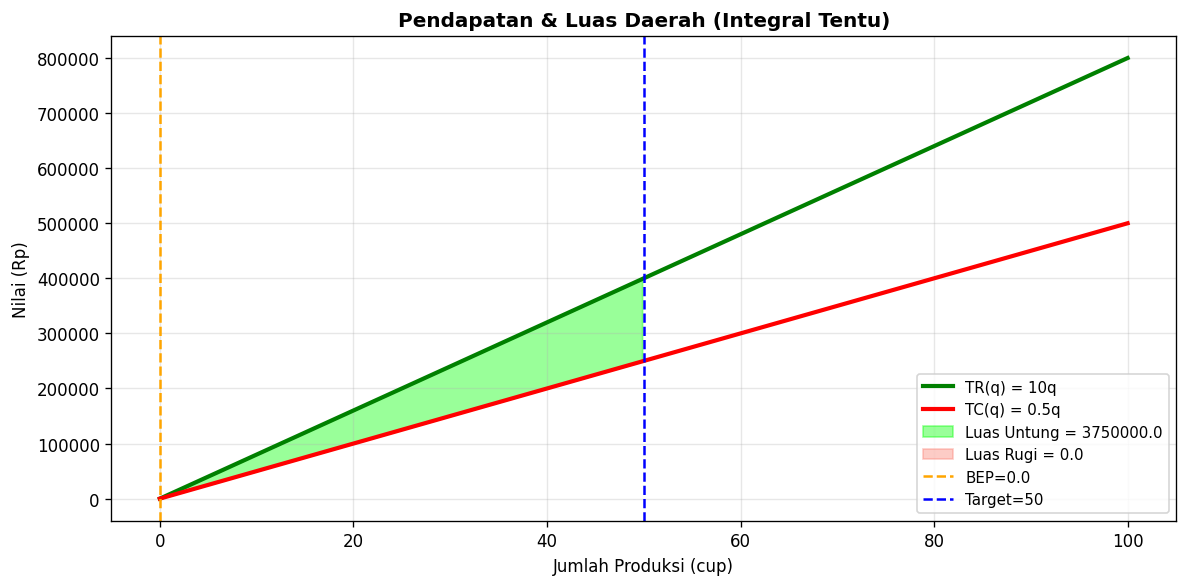

In [16]:
q_target = 50  # target produksi harian

# Integral numerik – luas area untung dari BEP ke q_target
luas_untung, _ = integrate.quad(lambda q: TR(q) - TC(q), bep, q_target)
# Integral numerik – luas area rugi dari 0 ke BEP
luas_rugi, _   = integrate.quad(lambda q: abs(TR(q) - TC(q)), 0, bep)

print('='*50)
print('📐  ANALISIS LUAS DAERAH (Integral)')
print('='*50)
print(f'Luas zona RUGI  (0 → BEP)          : Rp {luas_rugi:.2f}')
print(f'Luas zona UNTUNG (BEP → {q_target})   : Rp {luas_untung:.2f}')
print(f'Net Profit pada q={q_target}            : Rp {profit(q_target):.2f}')

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(q_arr, TR(q_arr), 'g-', lw=2.5, label='TR(q) = 10q')
ax.plot(q_arr, TC(q_arr), 'r-', lw=2.5, label='TC(q) = 0.5q')
ax.fill_between(q_arr, TC(q_arr), TR(q_arr),
                where=(q_arr >= bep) & (q_arr <= q_target),
                color='lime', alpha=0.4, label=f'Luas Untung = {luas_untung:.1f}')
ax.fill_between(q_arr, TC(q_arr), TR(q_arr),
                where=(q_arr < bep),
                color='salmon', alpha=0.4, label=f'Luas Rugi = {luas_rugi:.1f}')
ax.axvline(bep, color='orange', ls='--', lw=1.5, label=f'BEP={bep:.1f}')
ax.axvline(q_target, color='blue', ls='--', lw=1.5, label=f'Target={q_target}')
ax.set_xlabel('Jumlah Produksi (cup)')
ax.set_ylabel('Nilai (Rp)')
ax.set_title('Pendapatan & Luas Daerah (Integral Tentu)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. 🫙 Desain Volume Botol (Tabung Terpancung)
**Rumus:** $ V = \frac{\pi}{3} h (r_1^2 + r_1 r_2 + r_2^2) $

Volume Botol (Frustum) : 505.0110 cm³  ≈ 505.01 mL
Volume via Integral    : 505.0110 cm³  (verifikasi)
Selisih                : 0.000000 cm³


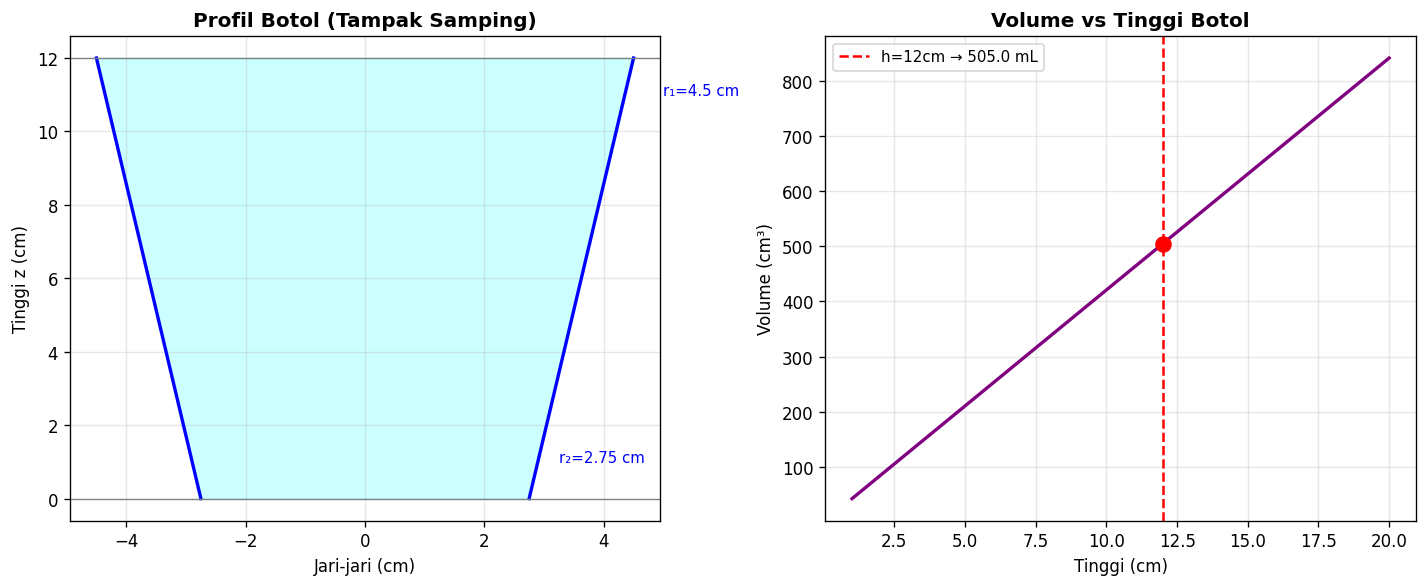

In [17]:
# Volume Tabung Terpancung (Frustum)
V_frustum = (np.pi / 3) * tinggi * (r1**2 + r1*r2 + r2**2)
print(f'Volume Botol (Frustum) : {V_frustum:.4f} cm³  ≈ {V_frustum:.2f} mL')

# Integral – Volume via integrasi jari-jari
# r(z) = r2 + (r1-r2)*(z/h) linierkan dari bawah ke atas
r_z = lambda z: r2 + (r1 - r2) * (z / tinggi)
V_integral, _ = integrate.quad(lambda z: np.pi * r_z(z)**2, 0, tinggi)
print(f'Volume via Integral    : {V_integral:.4f} cm³  (verifikasi)')
print(f'Selisih                : {abs(V_frustum - V_integral):.6f} cm³')

# Visualisasi 2D – profil botol
z_arr = np.linspace(0, tinggi, 200)
r_arr = r_z(z_arr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.plot( r_arr, z_arr, 'b-', lw=2)
ax.plot(-r_arr, z_arr, 'b-', lw=2)
ax.fill_betweenx(z_arr, -r_arr, r_arr, alpha=0.2, color='cyan')
ax.axhline(0,      color='gray', lw=0.8)
ax.axhline(tinggi, color='gray', lw=0.8)
ax.set_xlabel('Jari-jari (cm)')
ax.set_ylabel('Tinggi z (cm)')
ax.set_title('Profil Botol (Tampak Samping)', fontweight='bold')
ax.annotate(f'r₁={r1} cm', xy=(r1, tinggi), xytext=(r1+0.5, tinggi-1), fontsize=9, color='blue')
ax.annotate(f'r₂={r2} cm', xy=(r2, 0),      xytext=(r2+0.5, 1),        fontsize=9, color='blue')

# Volume vs tinggi
ax2 = axes[1]
h_arr = np.linspace(1, 20, 200)
V_arr = (np.pi/3) * h_arr * (r1**2 + r1*r2 + r2**2)
ax2.plot(h_arr, V_arr, 'purple', lw=2)
ax2.axvline(tinggi, color='red', ls='--', label=f'h={tinggi}cm → {V_frustum:.1f} mL')
ax2.scatter([tinggi], [V_frustum], color='red', s=80, zorder=5)
ax2.set_xlabel('Tinggi (cm)')
ax2.set_ylabel('Volume (cm³)')
ax2.set_title('Volume vs Tinggi Botol', fontweight='bold')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. 📈 Model Pertumbuhan Penjualan (Eksponensial)
**Rumus:** $ P(t) = P_0 \cdot e^{rt} $

di mana $P_0$ = penjualan awal, $r$ = laju pertumbuhan, $t$ = waktu (hari)

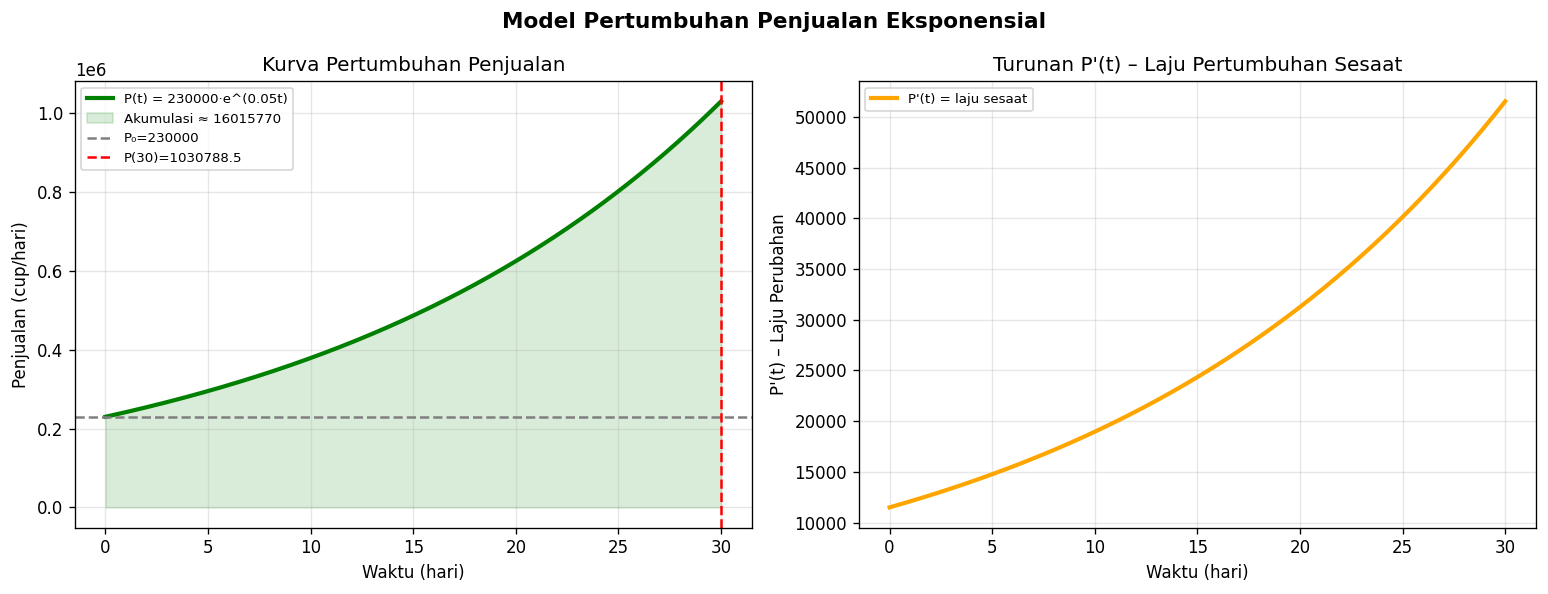

📈  HASIL MODEL EKSPONENSIAL
Penjualan Awal P₀    : 230000 cup/hari
Laju Pertumbuhan r   : 5%/hari
Penjualan di t=30   : 1030788.49 cup/hari
Total Akumulasi      : 16015769.72 cup
Pertumbuhan Absolut  : 800788.49 cup/hari (+348.2%)


In [18]:
P0 = pendapatan_bersih  # penjualan awal (cup/hari)
r_growth = 0.05         # 5% per hari
T = 30                  # 30 hari

t_arr = np.linspace(0, T, 300)
P_t = P0 * np.exp(r_growth * t_arr)
P_T = P0 * np.exp(r_growth * T)

# Turunan P'(t) = r * P(t) — laju pertumbuhan sesaat
dP_dt = r_growth * P_t

# Total akumulasi via integral
total_akum, _ = integrate.quad(lambda t: P0 * np.exp(r_growth * t), 0, T)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Pertumbuhan Penjualan Eksponensial', fontweight='bold', fontsize=13)

ax = axes[0]
ax.plot(t_arr, P_t, 'g-', lw=2.5, label=f'P(t) = {P0}·e^(0.05t)')
ax.fill_between(t_arr, P_t, alpha=0.15, color='green', label=f'Akumulasi ≈ {total_akum:.0f}')
ax.axhline(P0, color='gray', ls='--', label=f'P₀={P0}')
ax.axvline(T,  color='red',  ls='--', label=f'P({T})={P_T:.1f}')
ax.set_xlabel('Waktu (hari)')
ax.set_ylabel('Penjualan (cup/hari)')
ax.set_title('Kurva Pertumbuhan Penjualan')
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.plot(t_arr, dP_dt, 'orange', lw=2.5, label="P'(t) = laju sesaat")
ax2.set_xlabel('Waktu (hari)')
ax2.set_ylabel("P'(t) – Laju Perubahan")
ax2.set_title("Turunan P'(t) – Laju Pertumbuhan Sesaat")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('='*50)
print('📈  HASIL MODEL EKSPONENSIAL')
print('='*50)
print(f'Penjualan Awal P₀    : {P0} cup/hari')
print(f'Laju Pertumbuhan r   : {r_growth*100:.0f}%/hari')
print(f'Penjualan di t={T}   : {P_T:.2f} cup/hari')
print(f'Total Akumulasi      : {total_akum:.2f} cup')
print(f'Pertumbuhan Absolut  : {P_T - P0:.2f} cup/hari (+{((P_T/P0)-1)*100:.1f}%)')

---
## 5. 🎯 Optimasi Keuntungan (Turunan Pertama = 0)
**Model:** $ \pi(q) = TR(q) - TC(q) = p \cdot q - (c \cdot q + F) $

**Syarat Optimal:** $ \frac{d\pi}{dq} = p - c = 0 $ → Maksimum saat $p = MC$

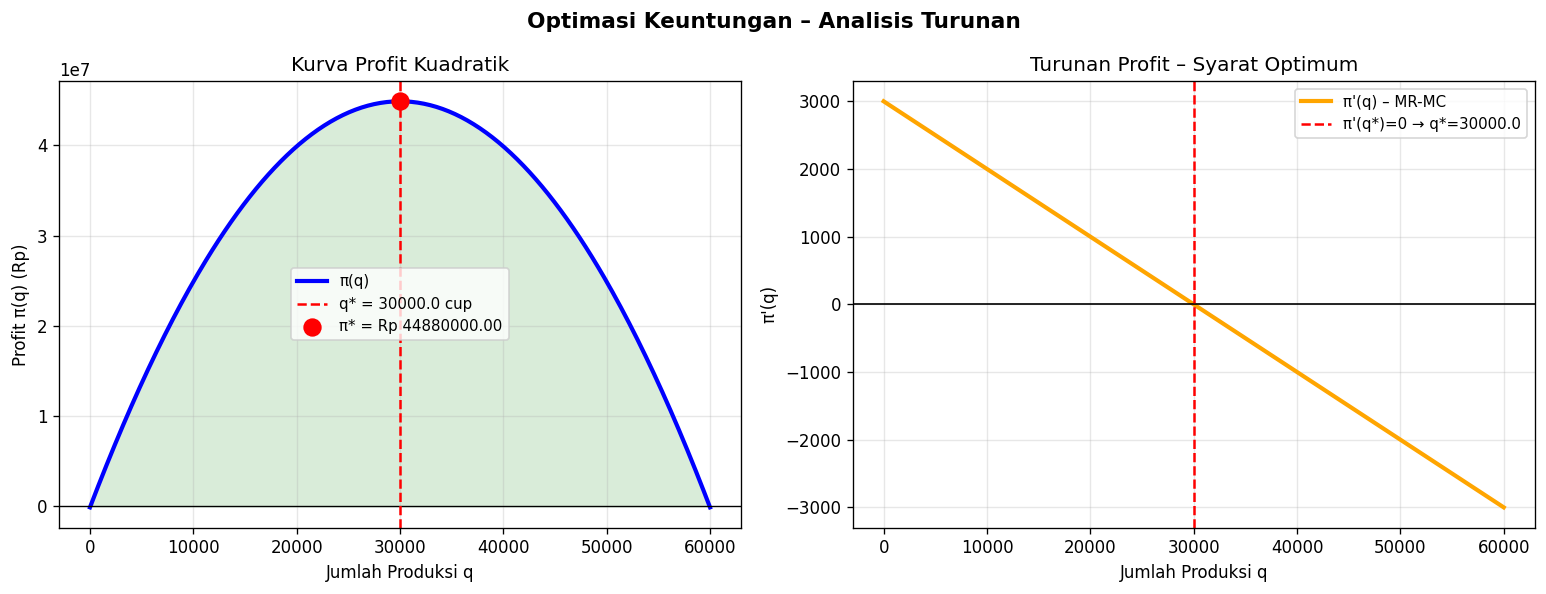

🎯  HASIL OPTIMASI
Jumlah Produksi Optimal q*  : 30000.00 cup
Profit Maksimum π*          : Rp 44880000.00
Verifikasi π'(q*)           : 0.000000 ≈ 0


In [19]:
# Model profit kuadratik lebih realistis: π(q) = -aq² + bq - c
# Misal: harga turun seiring volume (demand curve)
# p(q) = harga_jual - 0.05q
a_coef = 0.05   # koefisien demand
F      = modal_awal  # biaya tetap

pi_q = lambda q: (harga_jual - a_coef * q) * q - modal_per_cup * q - F
dpi_dq = lambda q: harga_jual - 2 * a_coef * q - modal_per_cup

# Titik optimal: dπ/dq = 0
q_star = (harga_jual - modal_per_cup) / (2 * a_coef)
pi_star = pi_q(q_star)

q_range = np.linspace(0, 2 * q_star, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Optimasi Keuntungan – Analisis Turunan', fontweight='bold', fontsize=13)

ax = axes[0]
ax.plot(q_range, pi_q(q_range), 'b-', lw=2.5, label='π(q)')
ax.axhline(0, color='k', lw=0.8)
ax.axvline(q_star, color='red', ls='--', label=f'q* = {q_star:.1f} cup')
ax.scatter([q_star], [pi_star], s=100, color='red', zorder=5, label=f'π* = Rp {pi_star:.2f}')
ax.fill_between(q_range, pi_q(q_range), 0, where=(pi_q(q_range) > 0), alpha=0.15, color='green')
ax.set_xlabel('Jumlah Produksi q')
ax.set_ylabel('Profit π(q) (Rp)')
ax.set_title('Kurva Profit Kuadratik')
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(q_range, dpi_dq(q_range), 'orange', lw=2.5, label="π'(q) – MR-MC")
ax2.axhline(0, color='k', lw=1)
ax2.axvline(q_star, color='red', ls='--', label=f"π'(q*)=0 → q*={q_star:.1f}")
ax2.set_xlabel('Jumlah Produksi q')
ax2.set_ylabel("π'(q)")
ax2.set_title("Turunan Profit – Syarat Optimum")
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()
# walktrough penyusunan kalibrasi
print('='*50)
print('🎯  HASIL OPTIMASI')
print('='*50)
print(f'Jumlah Produksi Optimal q*  : {q_star:.2f} cup')
print(f'Profit Maksimum π*          : Rp {pi_star:.2f}')
print(f'Verifikasi π\'(q*)           : {dpi_dq(q_star):.6f} ≈ 0')

---
## 6. 🤖 Model Machine Learning
### 6a. Regresi Polinomial – Prediksi Profit

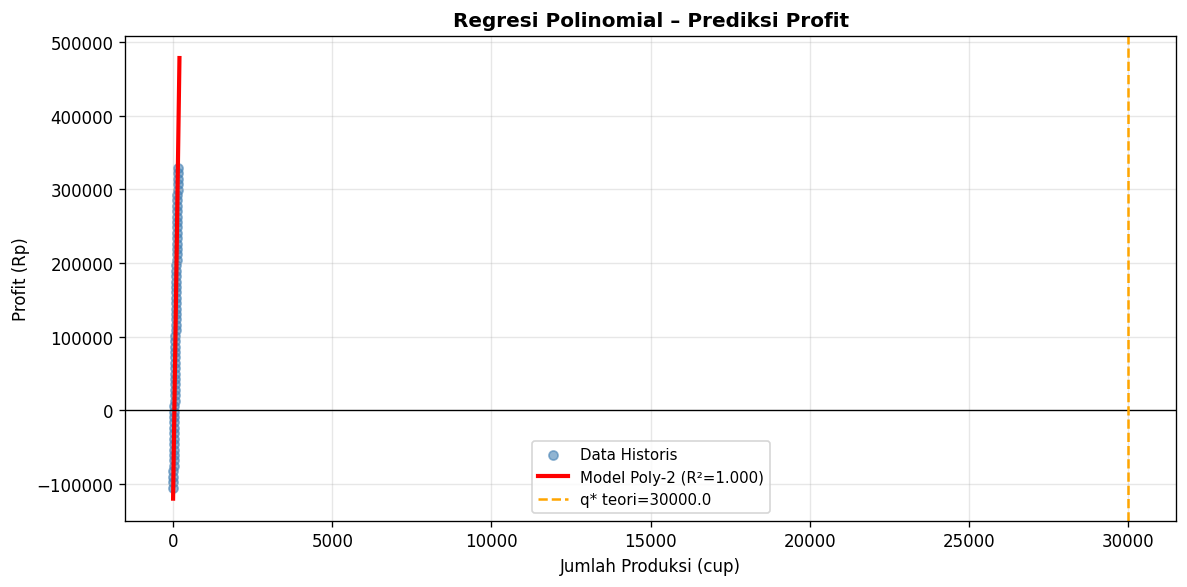

🤖  EVALUASI MODEL ML (Polynomial Regression)
R² Score  : 1.0000
RMSE      : 12.5656
Prediksi profit q=50  : Rp 29869.64
Prediksi profit q=95  : Rp 164543.21


In [20]:
np.random.seed(42)
# Simulasi data historis produksi & profit
q_hist = np.linspace(5, 150, 60)
noise  = np.random.normal(0, 15, 60)
pi_hist = pi_q(q_hist) + noise

# Train/test split manual (80/20)
split = int(0.8 * len(q_hist))
X_train, X_test = q_hist[:split].reshape(-1,1), q_hist[split:].reshape(-1,1)
y_train, y_test = pi_hist[:split],               pi_hist[split:]

# Model Polinomial derajat 2
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_train, y_train)
y_pred = model_poly.predict(X_test)

r2  = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

q_plot = np.linspace(0, 200, 300).reshape(-1,1)
pi_pred_full = model_poly.predict(q_plot)

plt.figure(figsize=(10, 5))
plt.scatter(q_hist, pi_hist, alpha=0.6, s=30, label='Data Historis', color='steelblue')
plt.plot(q_plot, pi_pred_full, 'r-', lw=2.5, label=f'Model Poly-2 (R²={r2:.3f})')
plt.axhline(0,       color='k',      lw=0.8)
plt.axvline(q_star,  color='orange', ls='--', lw=1.5, label=f'q* teori={q_star:.1f}')
plt.xlabel('Jumlah Produksi (cup)')
plt.ylabel('Profit (Rp)')
plt.title('Regresi Polinomial – Prediksi Profit', fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('='*50)
print('🤖  EVALUASI MODEL ML (Polynomial Regression)')
print('='*50)
print(f'R² Score  : {r2:.4f}')
print(f'RMSE      : {rmse:.4f}')
print(f'Prediksi profit q=50  : Rp {model_poly.predict([[50]])[0]:.2f}')
print(f'Prediksi profit q=95  : Rp {model_poly.predict([[95]])[0]:.2f}')

### 6b. Model ML – Prediksi Pertumbuhan Penjualan (Time Series sederhana)

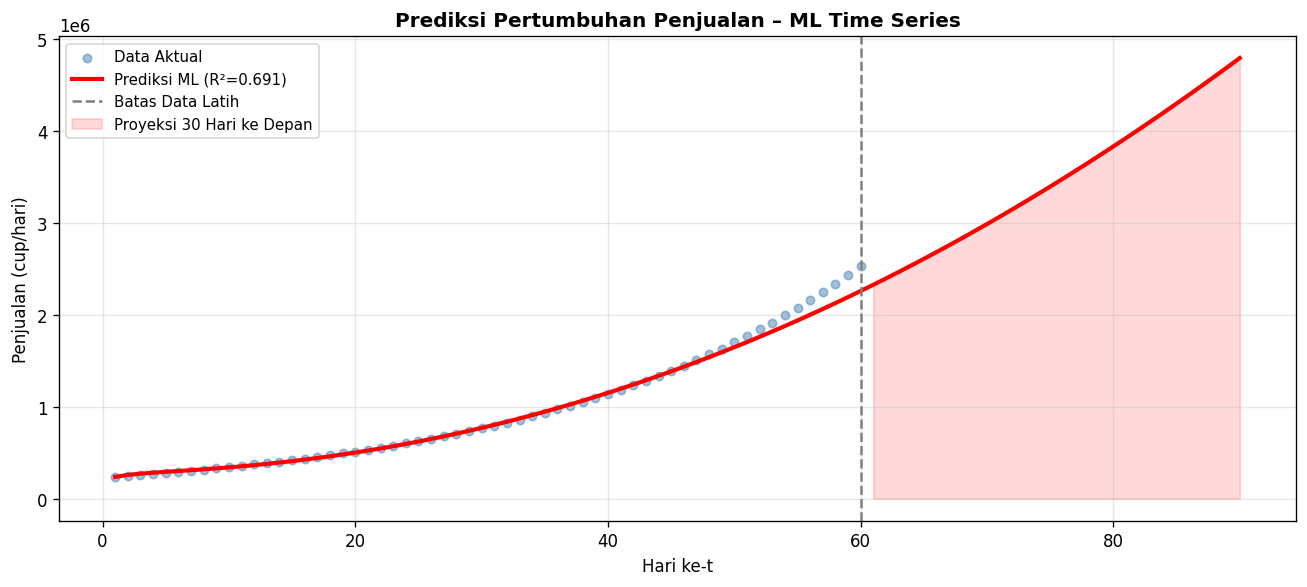

📈  EVALUASI MODEL PREDIKSI PENJUALAN
R² Score  : 0.6912
RMSE      : 157313.4834
Prediksi Penjualan Hari-90  : 4793964.93 cup/hari


In [21]:
from sklearn.linear_model import Ridge

# Simulasi data penjualan harian 60 hari
t_hist = np.arange(1, 61)
P_hist_true = P0 * np.exp(0.04 * t_hist)
P_hist_noisy = P_hist_true + np.random.normal(0, 20, 60)

# Feature: [t, t², ln(t)]
def build_features(t):
    t = t.reshape(-1, 1)
    return np.hstack([t, t**2, np.log(t)])

X_ts = build_features(t_hist.astype(float))
split_ts = 48
X_tr, X_te = X_ts[:split_ts], X_ts[split_ts:]
y_tr, y_te = P_hist_noisy[:split_ts], P_hist_noisy[split_ts:]

model_ts = Ridge(alpha=1.0)
model_ts.fit(X_tr, y_tr)

t_future = np.arange(1, 91).astype(float)
X_future = build_features(t_future)
P_future_pred = model_ts.predict(X_future)

r2_ts   = r2_score(y_te, model_ts.predict(X_te))
rmse_ts = np.sqrt(mean_squared_error(y_te, model_ts.predict(X_te)))

plt.figure(figsize=(11, 5))
plt.scatter(t_hist, P_hist_noisy, alpha=0.5, s=25, color='steelblue', label='Data Aktual')
plt.plot(t_future, P_future_pred, 'r-', lw=2.5, label=f'Prediksi ML (R²={r2_ts:.3f})')
plt.axvline(60, color='gray', ls='--', lw=1.5, label='Batas Data Latih')
plt.fill_between(t_future[t_future > 60], P_future_pred[t_future > 60],
                 alpha=0.15, color='red', label='Proyeksi 30 Hari ke Depan')
plt.xlabel('Hari ke-t')
plt.ylabel('Penjualan (cup/hari)')
plt.title('Prediksi Pertumbuhan Penjualan – ML Time Series', fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('='*50)
print('📈  EVALUASI MODEL PREDIKSI PENJUALAN')
print('='*50)
print(f'R² Score  : {r2_ts:.4f}')
print(f'RMSE      : {rmse_ts:.4f}')
print(f'Prediksi Penjualan Hari-90  : {P_future_pred[-1]:.2f} cup/hari')

---
## 📊 Ringkasan Akhir – Semua Model

   RINGKASAN SEMUA MODEL KALKULUS & ML
                    Indikator        Nilai
              Modal Awal (Rp) 1.200000e+05
  Pendapatan Bersih/Hari (Rp) 2.300000e+05
          Keuntungan/Cup (Rp) 9.999500e+03
                    BEP (cup) 0.000000e+00
    Luas Area Untung (q=0-50) 3.750000e+06
           Volume Botol (cm³) 5.050110e+02
Penjualan Proyeksi t=30 (cup) 1.030788e+06
Total Akumulasi 30 Hari (cup) 1.601577e+07
    Produksi Optimal q* (cup) 3.000000e+04
      Profit Maksimum π* (Rp) 4.488000e+07
                   ML Poly R² 1.000000e+00
            ML Time-Series R² 6.912000e-01


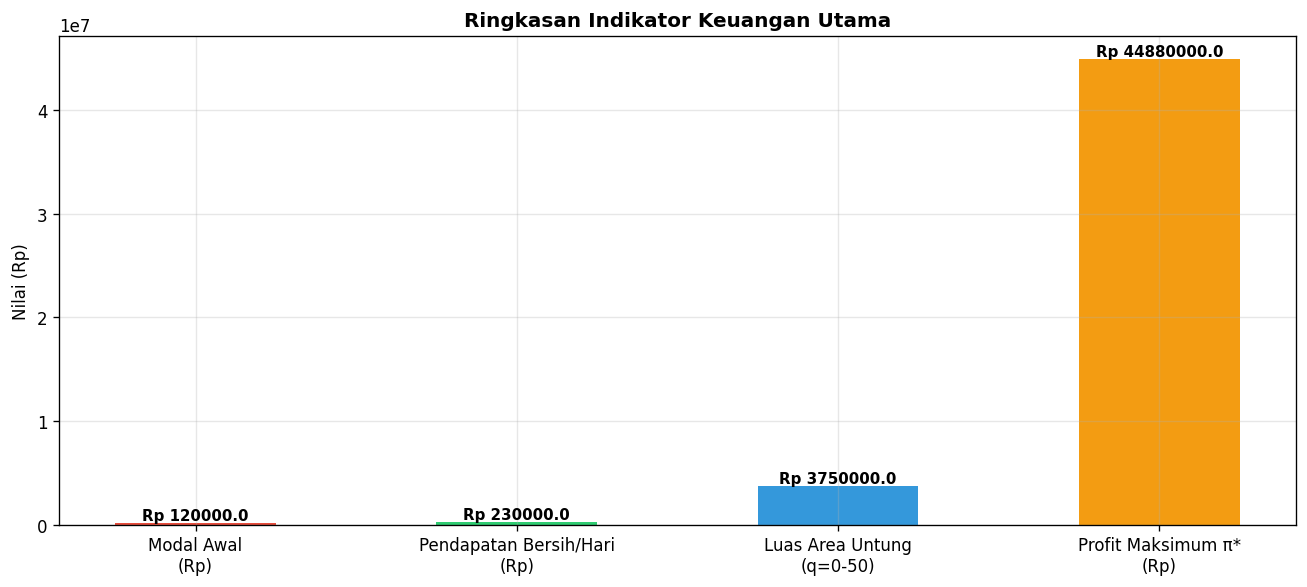

In [22]:
print('='*60)
print('   RINGKASAN SEMUA MODEL KALKULUS & ML')
print('='*60)
results = {
    'Modal Awal (Rp)'                : modal_awal,
    'Pendapatan Bersih/Hari (Rp)'    : pendapatan_bersih,
    'Keuntungan/Cup (Rp)'            : keuntungan_per_cup,
    'BEP (cup)'                      : round(bep, 2),
    'Luas Area Untung (q=0-50)'      : round(luas_untung, 2),
    'Volume Botol (cm³)'             : round(V_frustum, 4),
    'Penjualan Proyeksi t=30 (cup)'  : round(P_T, 2),
    'Total Akumulasi 30 Hari (cup)'  : round(total_akum, 2),
    'Produksi Optimal q* (cup)'      : round(q_star, 2),
    'Profit Maksimum π* (Rp)'        : round(pi_star, 2),
    'ML Poly R²'                     : round(r2, 4),
    'ML Time-Series R²'              : round(r2_ts, 4),
}
df_summary = pd.DataFrame(list(results.items()), columns=['Indikator', 'Nilai'])
print(df_summary.to_string(index=False))

# Bar chart ringkasan nilai kunci
fig, ax = plt.subplots(figsize=(11, 5))
keys_plot = ['Modal Awal (Rp)', 'Pendapatan Bersih/Hari (Rp)',
             'Luas Area Untung (q=0-50)', 'Profit Maksimum π* (Rp)']
vals_plot = [results[k] for k in keys_plot]
colors_bar = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']
bars = ax.bar([k.replace(' (','\n(') for k in keys_plot], vals_plot, color=colors_bar, width=0.5)
for bar, val in zip(bars, vals_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'Rp {val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Nilai (Rp)')
ax.set_title('Ringkasan Indikator Keuangan Utama', fontweight='bold')
plt.tight_layout()
plt.show()